# Temporal Predictive Coding on the Symbolic Benchmark

**Model:** `TemporalPCNetwork` / `MultilayerTemporalPCNetwork`
([`memval/models/baselines/temporal_pc.py`](../memval/models/baselines/temporal_pc.py))

A NumPy port of **temporal predictive coding** (tPC) — Tang, Barron & Bogacz,
*Sequential Memory with Temporal Predictive Coding*, NeurIPS 2023
([paper](https://arxiv.org/abs/2305.11982),
[reference code](https://github.com/C16Mftang/sequential-memory)).

MemVal's first non-EP biologically-plausible arm. Where EP learns from the
difference between two settled states (a contrastive rule needing two relaxation
phases), tPC learns from an explicit **prediction error**: predict the next
observation, and every weight update is an outer product of a local error with a
local activation. One phase, no nudging.

$$
\mathcal{F} = \underbrace{\lVert z_t - W_r f(z_{t-1})\rVert^2}_{\varepsilon_z}
            + \underbrace{\lVert x_t - W_{out} f(z_t)\rVert^2}_{\varepsilon_x}
\qquad
\Delta W_r \propto \varepsilon_z \otimes f(z_{t-1}), \quad
\Delta W_{out} \propto \varepsilon_x \otimes f(z_t)
$$

**What this notebook covers**

1. The model in one cell — does it learn a list?
2. The whitening theorem, made visible (why tPC ≠ AsymmetricHopfield)
3. The full symbolic suite, head-to-head
4. Catastrophic forgetting: retention matrices
5. **The load sweep** — where the benchmark actually discriminates
6. Knobs to explore

> **Read section 5 before drawing conclusions from section 4.** At the suite's
> default scale, tPC and AHN both sit at ceiling, and the forgetting numbers
> there are not informative.

## 0. Setup

In [1]:
import os
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from memval.encoders.symbolic import SymbolicEncoder, SymbolicDecoder
from memval.benchmarks.symbolic_pipeline import (
    measure_recall_associative,
    mean_recall_rate,
    run_symbolic_pipeline,
)
from memval.models.baselines import (
    TemporalPCNetwork,
    MultilayerTemporalPCNetwork,
    AsymmetricHopfieldNetwork,
    OriginalEqPropSequenceNetwork,
)

EMBED_DIM = 100
CATEGORY_VARIANCE = 0.2
NOISE_SCALE = 0.05
plt.rcParams["figure.dpi"] = 110

print("numpy", np.__version__)

numpy 2.4.6


In [2]:
def make_encoder(lists, seed=0, one_category=False):
    """Encoder/decoder for a dict of {list_name: [words]}.

    `one_category=True` puts every word in the same semantic category, which
    raises the cross-list similarity — the overlap knob.
    """
    vocab = {w: ("shared" if one_category else name)
             for name, words in lists.items() for w in words}
    enc = SymbolicEncoder(vocab, embedding_dim=EMBED_DIM,
                          category_variance=CATEGORY_VARIANCE, seed=seed)
    return enc, SymbolicDecoder(enc)


def score(model, words, enc, dec, n_trials=20, noise=NOISE_SCALE, eval_seed=10_000):
    """One-step cued-recall MRR, with the eval noise pinned for comparability."""
    model.reset_context()
    np.random.seed(eval_seed)
    return mean_recall_rate(
        measure_recall_associative(model, words, enc, dec,
                                   n_trials=n_trials, noise_scale=noise))


def cross_list_cosine(lists, enc):
    """Mean pairwise cosine between items of *different* lists (0 = orthogonal)."""
    embs = {k: enc.encode(v) for k, v in lists.items()}
    names, vals = list(lists), []
    for a in range(len(names)):
        for b in range(a + 1, len(names)):
            for u in embs[names[a]]:
                for v in embs[names[b]]:
                    vals.append(u @ v / (np.linalg.norm(u) * np.linalg.norm(v)))
    return float(np.mean(vals))

## 1. The model in one cell

Train on a single 5-item list and decode what it predicts. `predict_next(x_t)`
should return something that decodes to $x_{t+1}$.

In [3]:
FRUIT = ["apple", "banana", "orange", "grape", "pear"]
lists_1 = {"L0": FRUIT}
enc, dec = make_encoder(lists_1, seed=0)
emb = enc.encode(FRUIT)

print(f"embeddings: {emb.shape}, unit-norm={np.allclose(np.linalg.norm(emb, axis=1), 1)}, "
      f"{np.mean(emb < 0):.0%} negative\n")

models = {
    "tPC 1-layer":  TemporalPCNetwork(n_features=EMBED_DIM, learning_rate=0.01,
                                      n_epochs=300, seed=0),
    "tPC 2-layer":  MultilayerTemporalPCNetwork(n_features=EMBED_DIM, n_hidden=128,
                                                learning_rate=0.05, n_epochs=200, seed=0),
    "AsymHopfield": AsymmetricHopfieldNetwork(n_features=EMBED_DIM, learning_rate=0.1),
    "EqProp":       OriginalEqPropSequenceNetwork(n_features=EMBED_DIM, n_hidden=128,
                                                  learning_rate=0.1, n_epochs=300, beta=0.5,
                                                  activation="tanh", output_activation="tanh",
                                                  seed=0),
}

for name, m in models.items():
    t0 = time.time()
    m.fit_sequence(emb, epochs=300)
    mrr = score(m, FRUIT, enc, dec)
    chain = [dec.decode(v, top_k=1)[0] for v in m.recall(emb[0], length=4)]
    print(f"{name:<14} MRR={mrr:.3f}  train={time.time()-t0:5.2f}s  recall: {chain}")

print(f"{'target':<14}                              {FRUIT[1:]}")

embeddings: (5, 100), unit-norm=True, 50% negative

tPC 1-layer    MRR=1.000  train= 0.02s  recall: ['banana', 'orange', 'grape', 'pear']
tPC 2-layer    MRR=1.000  train= 1.16s  recall: ['banana', 'orange', 'grape', 'pear']
AsymHopfield   MRR=1.000  train= 0.02s  recall: ['banana', 'orange', 'grape', 'pear']
EqProp         MRR=0.988  train= 1.64s  recall: ['banana', 'pear', 'pear', 'pear']
target                                      ['banana', 'orange', 'grape', 'pear']


All four learn a single list. Note `recall` differs in kind between them: the
observation-space models feed each prediction back as the next input, while the
2-layer tPC rolls forward in *latent* space and reads out — so it doesn't suffer
the magnitude drift that autoregressive feedback causes.

## 2. The whitening theorem, made visible

The paper's key theoretical result: **single-layer tPC is an Asymmetric Hopfield
Network with an implicit whitening** of the input covariance. Where AHN sets

$$W_{AHN} = \sum_t x_{t+1} x_t^\top$$

gradient descent on the tPC energy converges to

$$W_{tPC} = \Big(\sum_t x_{t+1}x_t^\top\Big)\Big(\sum_t x_t x_t^\top\Big)^{-1}$$

Same architecture; the covariance inverse is the only difference. Let's check the
trained weights actually land there — this is also the sharpest test that the
port is faithful.

In [4]:
seq = enc.encode(FRUIT)
X_prev, X_next = seq[:-1], seq[1:]

C_cross = X_next.T @ X_prev              # AHN weight (outer-product memory)
C_auto  = X_prev.T @ X_prev              # input covariance
W_white = C_cross @ np.linalg.pinv(C_auto)   # the whitened solution

# linear nonlinearity so the correspondence is exact
m_lin = TemporalPCNetwork(n_features=EMBED_DIM, learning_rate=0.05,
                          n_epochs=5000, nonlinearity="linear", seed=0)
m_lin.fit_sequence(seq)

def reconstruction_error(W):
    return np.linalg.norm(X_next - X_prev @ W.T)

print(f"‖W_tPC − W_whitened‖ = {np.linalg.norm(m_lin.W_r - W_white):.4f}")
print(f"‖W_tPC − W_AHN‖      = {np.linalg.norm(m_lin.W_r - C_cross):.4f}\n")
print("one-step reconstruction error (lower = better):")
print(f"  tPC (trained)  {reconstruction_error(m_lin.W_r):.4f}")
print(f"  whitened form  {reconstruction_error(W_white):.4f}")
print(f"  AHN            {reconstruction_error(C_cross):.4f}")

‖W_tPC − W_whitened‖ = 0.0000
‖W_tPC − W_AHN‖      = 0.6608

one-step reconstruction error (lower = better):
  tPC (trained)  0.0000
  whitened form  0.0000
  AHN            0.7533


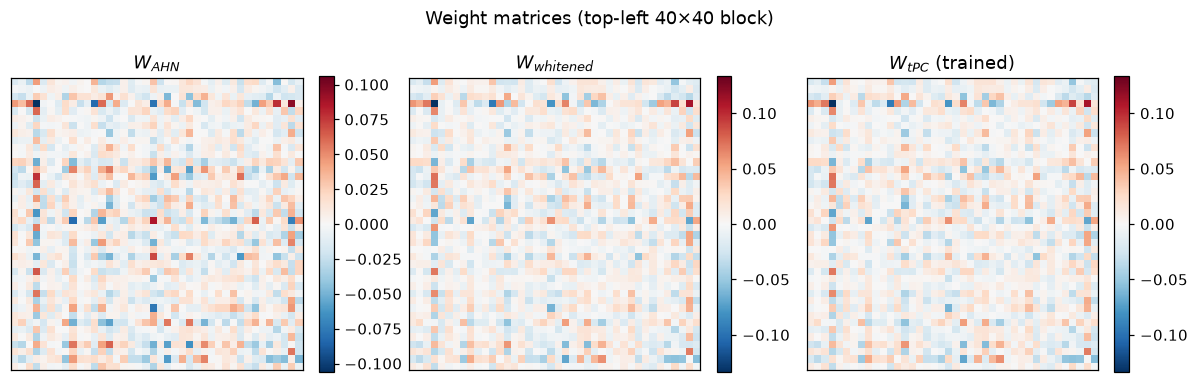

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, (W, title) in zip(axes, [(C_cross, "$W_{AHN}$"),
                                 (W_white, "$W_{whitened}$"),
                                 (m_lin.W_r, "$W_{tPC}$ (trained)")]):
    v = np.abs(W[:40, :40]).max()
    im = ax.imshow(W[:40, :40], cmap="RdBu_r", vmin=-v, vmax=v)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Weight matrices (top-left 40×40 block)", y=1.02)
plt.tight_layout(); plt.show()

The trained tPC weights sit on the whitened solution, not on the raw
outer-product one. Section 5 shows what that buys.

## 3. The full symbolic suite

`run_symbolic_pipeline` runs the standard sections against any model conforming
to `HippocampalModel`. The `sequence_length` and `multiple_sequences` sections
are the fast, informative ones.

In [6]:
OUT = "../results/_notebook_tpc"

SUITE = {
    "tPC 1-layer":  (TemporalPCNetwork,       dict(learning_rate=0.01, n_epochs=200, seed=0)),
    "tPC 2-layer":  (MultilayerTemporalPCNetwork,
                     dict(n_hidden=128, learning_rate=0.05, n_epochs=200, seed=0)),
    "AsymHopfield": (AsymmetricHopfieldNetwork, dict(learning_rate=0.1)),
    "EqProp":       (OriginalEqPropSequenceNetwork,
                     dict(n_hidden=128, learning_rate=0.1, n_epochs=200, beta=0.5,
                          activation="tanh", output_activation="tanh", seed=0)),
}

rows = {}
for name, (cls, kw) in SUITE.items():
    t0 = time.time()
    rows[name] = run_symbolic_pipeline(
        cls, model_kwargs=kw, output_dir=OUT, n_trials=10,
        benchmarks=["sequence_length", "multiple_sequences"])
    print(f"{name:<14} done in {time.time()-t0:5.1f}s")

[symbolic] running benchmarks: ['sequence_length', 'multiple_sequences']
Running Sequence Length benchmarks... (epochs=200)
Running Multiple Sequences interference benchmarks... (epochs=200)
Symbolic pipeline finished successfully for TemporalPCNetwork. Results saved to ../results/_notebook_tpc/TemporalPCNetwork/symbolic
tPC 1-layer    done in   0.3s
[symbolic] running benchmarks: ['sequence_length', 'multiple_sequences']
Running Sequence Length benchmarks... (epochs=200)
Running Multiple Sequences interference benchmarks... (epochs=200)
Symbolic pipeline finished successfully for MultilayerTemporalPCNetwork. Results saved to ../results/_notebook_tpc/MultilayerTemporalPCNetwork/symbolic
tPC 2-layer    done in   8.7s
[symbolic] running benchmarks: ['sequence_length', 'multiple_sequences']
Running Sequence Length benchmarks... (epochs=300)
Running Multiple Sequences interference benchmarks... (epochs=300)
Symbolic pipeline finished successfully for AsymmetricHopfieldNetwork. Results save

In [7]:
KEYS = ["max_memory_span", "multiple_seq_mrr_before",
        "multiple_seq_mrr_after", "delta_mrr_forgetting"]

print(f"{'model':<14}" + "".join(f"{k.replace('multiple_seq_','')[:16]:>18}" for k in KEYS))
print("-" * (14 + 18 * len(KEYS)))
for name, m in rows.items():
    cells = []
    for k in KEYS:
        v = m.get(k)
        cells.append(f"{v:>18.3f}" if isinstance(v, (int, float)) else f"{str(v):>18}")
    print(f"{name:<14}" + "".join(cells))

model            max_memory_span        mrr_before         mrr_after  delta_mrr_forget
--------------------------------------------------------------------------------------
tPC 1-layer               10.000             1.000             1.000             0.000
tPC 2-layer               10.000             1.000             1.000             0.000
AsymHopfield              10.000             1.000             1.000             0.000
EqProp                     2.000             0.950             0.250            -0.700


`delta_mrr_forgetting` is the suite's headline continual-learning number: recall
of list A before training on B, minus after. EP loses roughly half a point of
MRR; tPC and AHN lose nothing.

**Do not stop reading here.** "Loses nothing" is a ceiling reading — section 5.

## 4. Catastrophic forgetting: retention matrices

The standard continual protocol — train a chain of lists on the same weights, and
after each one re-test every list seen so far.

$$R[i,j] = \text{MRR on list } i \text{ after training through list } j$$

Read **down a column** for one list's decay; the **diagonal** is how well each
list was learned when fresh.

In [8]:
CHAIN = {
    "fruit":   ["apple", "banana", "orange", "grape", "pear"],
    "animal":  ["cat", "dog", "cow", "horse", "sheep"],
    "vehicle": ["car", "truck", "bus", "train", "plane"],
    "tool":    ["hammer", "wrench", "saw", "drill", "pliers"],
}

def retention_matrix(cls, kw, lists, seed=0, epochs=300, n_trials=10, one_category=False):
    enc, dec = make_encoder(lists, seed=seed, one_category=one_category)
    embs = {k: enc.encode(v) for k, v in lists.items()}
    names = list(lists)
    model = cls(n_features=EMBED_DIM, **kw)

    R = np.full((len(names), len(names)), np.nan)
    for j, nj in enumerate(names):
        model.fit_sequence(embs[nj], epochs=epochs)
        for i in range(j + 1):
            R[i, j] = score(model, lists[names[i]], enc, dec,
                            n_trials=n_trials, eval_seed=10_000 + i)
    return R, names


def summarize(R):
    final, diag = R[:, -1], np.diag(R)
    return float(np.mean(final)), float(np.mean(diag[:-1] - final[:-1]))

In [9]:
mats = {}
for name, (cls, kw) in SUITE.items():
    t0 = time.time()
    mats[name], chain_names = retention_matrix(cls, kw, CHAIN)
    acc, forg = summarize(mats[name])
    print(f"{name:<14} final_acc={acc:.3f}  forgetting={forg:.3f}  ({time.time()-t0:4.1f}s)")

enc_c, _ = make_encoder(CHAIN, seed=0)
print(f"\ncross-list cosine: {cross_list_cosine(CHAIN, enc_c):.3f}  (0 = orthogonal)")

tPC 1-layer    final_acc=1.000  forgetting=0.000  ( 0.1s)
tPC 2-layer    final_acc=1.000  forgetting=0.000  ( 4.7s)
AsymHopfield   final_acc=1.000  forgetting=0.000  ( 0.1s)
EqProp         final_acc=0.444  forgetting=0.700  ( 4.5s)

cross-list cosine: 0.005  (0 = orthogonal)


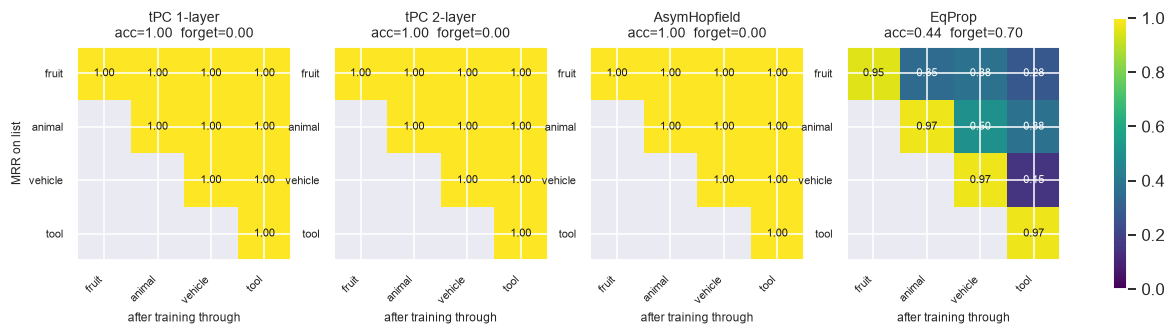

In [10]:
fig, axes = plt.subplots(1, len(mats), figsize=(3.1 * len(mats), 3.2))
for ax, (name, R) in zip(np.atleast_1d(axes), mats.items()):
    im = ax.imshow(np.ma.masked_invalid(R), cmap="viridis", vmin=0, vmax=1)
    acc, forg = summarize(R)
    ax.set_title(f"{name}\nacc={acc:.2f}  forget={forg:.2f}", fontsize=9)
    ax.set_xticks(range(len(chain_names)))
    ax.set_xticklabels(chain_names, rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(chain_names)))
    ax.set_yticklabels(chain_names, fontsize=7)
    ax.set_xlabel("after training through", fontsize=8)
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            if not np.isnan(R[i, j]):
                ax.text(j, i, f"{R[i,j]:.2f}", ha="center", va="center",
                        fontsize=7, color="w" if R[i, j] < 0.6 else "k")
np.atleast_1d(axes)[0].set_ylabel("MRR on list", fontsize=8)
fig.colorbar(im, ax=axes, fraction=0.02)
plt.show()

### Does overlap change it?

The obvious hypothesis is that the lists are simply too dissimilar. Put every
word in one semantic category and re-run — cross-list cosine goes from ~0.005 to
~0.23.

In [11]:
print(f"{'model':<14}{'final_acc':>12}{'forgetting':>13}")
print("-" * 39)
for name, (cls, kw) in SUITE.items():
    R, _ = retention_matrix(cls, kw, CHAIN, one_category=True)
    acc, forg = summarize(R)
    print(f"{name:<14}{acc:>12.3f}{forg:>13.3f}")

enc_o, _ = make_encoder(CHAIN, seed=0, one_category=True)
print(f"\ncross-list cosine now: {cross_list_cosine(CHAIN, enc_o):.3f}")

model            final_acc   forgetting
---------------------------------------
tPC 1-layer          1.000        0.000


tPC 2-layer          1.000        0.000
AsymHopfield         1.000        0.000


EqProp               0.694        0.333

cross-list cosine now: 0.229


Barely moves for tPC/AHN. Overlap is **not** the variable that separates these
models at this scale.

## 5. The load sweep — where the benchmark actually discriminates

Near-orthogonal patterns barely interfere in a **linear** outer-product memory,
and 4 lists × 5 items is only 16 transitions in 100 dimensions — far below
capacity. The discriminating variable is **load**.

This sweeps the number of lists and reports:

- **learnability** — mean MRR of each list right after it was learned (the diagonal)
- **final_acc** — mean MRR of every list after the whole chain
- **forgetting** — the difference

Both matter: a model that never learned can't forget, so a low forgetting number
means nothing without the learnability alongside it.

In [12]:
ITEMS_PER_LIST = 5

def make_lists(n_lists):
    return {f"L{k}": [f"w{k:03d}_{i}" for i in range(ITEMS_PER_LIST)]
            for k in range(n_lists)}


def load_point(cls, kw, n_lists, seed=0, epochs=200, n_trials=10):
    lists = make_lists(n_lists)
    enc, dec = make_encoder(lists, seed=seed)
    embs = {k: enc.encode(v) for k, v in lists.items()}
    names = list(lists)
    model = cls(n_features=EMBED_DIM, **kw)

    diag = np.zeros(n_lists)
    for j, nj in enumerate(names):
        model.fit_sequence(embs[nj], epochs=epochs)
        diag[j] = score(model, lists[nj], enc, dec, n_trials=n_trials, eval_seed=10_000 + j)
    final = np.array([score(model, lists[n], enc, dec, n_trials=n_trials, eval_seed=10_000 + i)
                      for i, n in enumerate(names)])
    return float(diag.mean()), float(final.mean())

In [13]:
# EqProp and the 2-layer tPC are much slower; trim LOADS or SWEEP_MODELS to taste.
LOADS = [4, 8, 12, 16, 20, 30]
SWEEP_MODELS = ["tPC 1-layer", "AsymHopfield", "tPC 2-layer", "EqProp"]
SEEDS = [0, 1, 2]

sweep = {}
for name in SWEEP_MODELS:
    cls, kw = SUITE[name]
    learn, final = [], []
    t0 = time.time()
    for n_lists in LOADS:
        pts = [load_point(cls, kw, n_lists, seed=s) for s in SEEDS]
        learn.append(np.mean([p[0] for p in pts]))
        final.append(np.mean([p[1] for p in pts]))
    sweep[name] = (np.array(learn), np.array(final))
    print(f"{name:<14} {time.time()-t0:5.0f}s")

tPC 1-layer        3s


AsymHopfield       4s


tPC 2-layer      218s


EqProp           303s


In [14]:
print(f"{'model':<14}{'lists':>7}{'transitions':>13}{'learnability':>14}"
      f"{'final_acc':>11}{'forgetting':>12}")
print("-" * 71)
for name, (learn, final) in sweep.items():
    for k, n_lists in enumerate(LOADS):
        print(f"{name:<14}{n_lists:>7}{n_lists * (ITEMS_PER_LIST - 1):>13}"
              f"{learn[k]:>14.3f}{final[k]:>11.3f}{learn[k] - final[k]:>12.3f}")
    print()

model           lists  transitions  learnability  final_acc  forgetting
-----------------------------------------------------------------------
tPC 1-layer         4           16         1.000      1.000       0.000
tPC 1-layer         8           32         1.000      1.000       0.000
tPC 1-layer        12           48         1.000      1.000       0.000
tPC 1-layer        16           64         1.000      0.999       0.001
tPC 1-layer        20           80         1.000      0.997       0.003
tPC 1-layer        30          120         1.000      0.953       0.047

AsymHopfield        4           16         1.000      1.000       0.000
AsymHopfield        8           32         1.000      1.000       0.000
AsymHopfield       12           48         1.000      0.983       0.017
AsymHopfield       16           64         1.000      0.949       0.051
AsymHopfield       20           80         1.000      0.916       0.084
AsymHopfield       30          120         1.000      0.743    

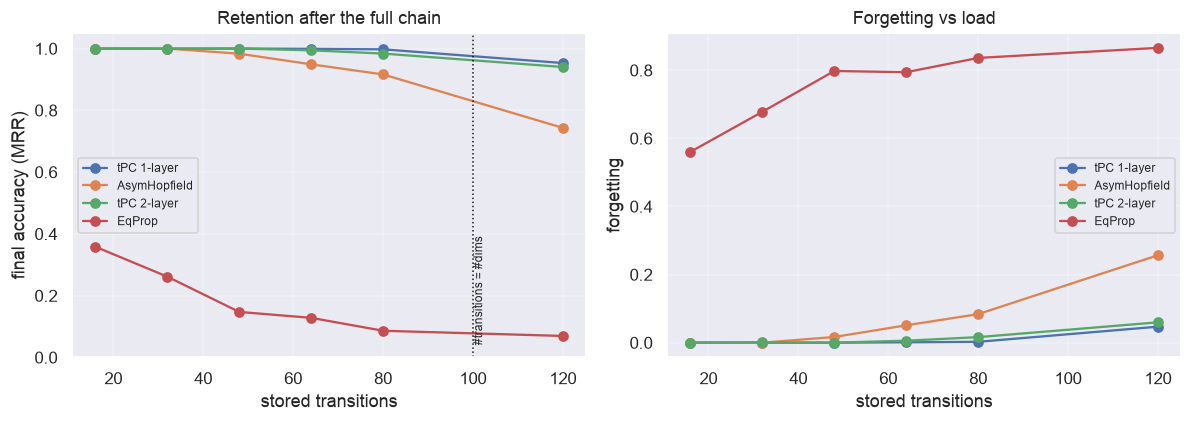

In [15]:
transitions = [n * (ITEMS_PER_LIST - 1) for n in LOADS]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

for name, (learn, final) in sweep.items():
    ax1.plot(transitions, final, "o-", label=name)
    ax2.plot(transitions, learn - final, "o-", label=name)

ax1.axvline(EMBED_DIM, ls=":", c="k", lw=1)
ax1.text(EMBED_DIM, 0.02, "  #transitions = #dims", fontsize=8, rotation=90, va="bottom")
ax1.set_xlabel("stored transitions"); ax1.set_ylabel("final accuracy (MRR)")
ax1.set_title("Retention after the full chain"); ax1.set_ylim(0, 1.05)
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2.set_xlabel("stored transitions"); ax2.set_ylabel("forgetting")
ax2.set_title("Forgetting vs load"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

### What to take from this

- **The 4-list chain is at ceiling** for tPC and AHN. Their section-4 forgetting
  of ~0 measures nothing about the models; it measures that the task is easy.
  EP forgets there for a different reason — its nonlinear *shared hidden layer* —
  so comparing the two at 4 lists compares a saturated model against an
  unsaturated one.
- **Past the knee the whitening pays off.** tPC and AHN are architecturally
  identical and differ only by the covariance inverse, yet tPC retains
  substantially more once load exceeds a few dozen transitions.
- **The latent buys nothing here.** 2-layer ≈ 1-layer throughout — expected, since
  these lists are first-order Markov with unique items, so there is nothing for a
  latent to remember. The place it should earn its keep is *disambiguation*
  (`A→B→X` vs `C→B→Y`), where a first-order model must fail by construction.

**Practical rule:** report continual results for associative-memory arms at loads
past the knee (≥ ~12 lists at 100 dims), or state explicitly that the small-chain
numbers are at ceiling.

## 6. Knobs to explore

Free parameters worth poking at. The tPC hyperparameters below came from one
coarse sweep on a 5-item list — they are **not** tuned, so there is real room here.

In [16]:
# --- tPC 1-layer: learning rate x nonlinearity -------------------------------
print("tPC 1-layer — single 5-item list")
print(f"{'lr':>8}{'tanh':>10}{'linear':>10}")
for lr in [0.001, 0.01, 0.05, 0.1]:
    row = []
    for nl in ["tanh", "linear"]:
        m = TemporalPCNetwork(n_features=EMBED_DIM, learning_rate=lr,
                              n_epochs=300, nonlinearity=nl, seed=0)
        m.fit_sequence(emb)
        row.append(score(m, FRUIT, enc, dec))
    print(f"{lr:>8}{row[0]:>10.3f}{row[1]:>10.3f}")

tPC 1-layer — single 5-item list
      lr      tanh    linear
   0.001     1.000     1.000
    0.01     1.000     1.000


    0.05     1.000     1.000
     0.1     1.000     1.000


In [17]:
# --- tPC 2-layer: latent width x inference iterations -------------------------
print("tPC 2-layer — single 5-item list")
print(f"{'n_hidden':>10}" + "".join(f"{f'inf={i}':>10}" for i in [10, 30, 100]))
for h in [32, 64, 128, 256]:
    row = []
    for it in [10, 30, 100]:
        m = MultilayerTemporalPCNetwork(n_features=EMBED_DIM, n_hidden=h,
                                        learning_rate=0.05, n_epochs=150,
                                        inf_iters=it, seed=0)
        m.fit_sequence(emb)
        row.append(score(m, FRUIT, enc, dec))
    print(f"{h:>10}" + "".join(f"{v:>10.3f}" for v in row))

tPC 2-layer — single 5-item list
  n_hidden    inf=10    inf=30   inf=100


        32     0.663     1.000     1.000


        64     0.975     1.000     1.000


       128     0.500     1.000     1.000


       256     0.988     1.000     1.000


In [18]:
# --- retrieval-cue noise robustness ------------------------------------------
noises = [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4]
print(f"{'model':<14}" + "".join(f"{f'σ={s}':>9}" for s in noises))
print("-" * (14 + 9 * len(noises)))
for name, m in models.items():
    print(f"{name:<14}" + "".join(
        f"{score(m, FRUIT, enc, dec, noise=s):>9.3f}" for s in noises))

model             σ=0.0   σ=0.01   σ=0.02   σ=0.05    σ=0.1    σ=0.2    σ=0.4
-----------------------------------------------------------------------------
tPC 1-layer       1.000    1.000    1.000    1.000    1.000    1.000    0.937


tPC 2-layer       1.000    1.000    1.000    1.000    1.000    1.000    0.900
AsymHopfield      1.000    1.000    1.000    1.000    1.000    1.000    0.925


EqProp            1.000    1.000    1.000    0.988    0.887    0.525    0.400


Cue-noise robustness is a separate axis from retention, and worth keeping
separate — a model can look like it "forgets" when it is really just
noise-sensitive. (That confound bit the DG variant earlier; see
[`docs/ep_continual_debugging_case_study.md`](../docs/ep_continual_debugging_case_study.md),
the Interlude.)

### Open threads

- **Disambiguation** (`A→B→X` vs `C→B→Y`) — the test the 2-layer latent should
  win and the 1-layer must lose. Not run yet.
- **Online / streaming.** Both models implement `fit_event`; the whole notebook
  above is batch. `memval/benchmarks/online_continual_pipeline.py` is the
  streaming harness.
- **Hyperparameters** — untuned, per above.
- **Diagnostics.** Both expose `named_representations`, `named_parameters` and
  `transition_grads`, so `memval/diagnostics/` (Jaccard, update-cosine, Fisher
  attribution) runs on them unmodified.